# Goal
The goal of this exercise is to build your own neural network that will determine what a 4-pixel camera sees.
This is the application that was presented in the lecture.

The input will be the values of 4 pixels.
- A value of -1 represents a completely black color
- A value of +1 represents a completely white color
- Values in between represent a proportional gray color

The pixels are given in a row, but geometrically they are arranged as follows.
- 1 2
- 3 4

The neural network should return information about whether the pixels in the image represent
- a solid color (solid) - all pixels have approximately the same color
- vertical lines (vertical) - one line is white, the other black, in any order
- diagonal lines (diagonal) - the image has two diagonal lines, one white, one black
- horizontal (horizontal) - the image has one horizontal white and one horizontal black line

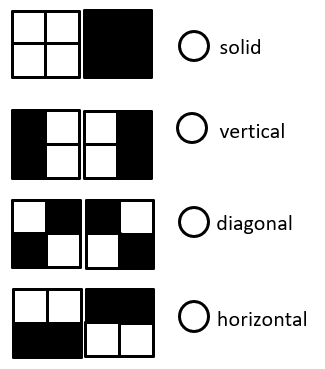

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import keras
from keras.layers import Dense, Activation, Input
from keras.models import Sequential

# Loading the data

In [2]:
data = pd.read_csv ("..\\dataset\\camera.csv", sep=";", decimal=",")

# Data description
- Displaying a sample of the data
- Basic statistical characteristics
- Distribution of the values

In [3]:
data.head()

,pixel1,pixel2,pixel3,pixel4,solid,vertical,diagonal,horizontal
0,0.242848,0.315426,0.225074,0.441009,1,0,0,0
1,0.212298,0.985880,0.700295,0.262448,1,0,0,0
2,0.259762,0.692340,0.393549,0.711056,1,0,0,0
3,0.733063,0.977552,0.327758,0.213178,1,0,0,0
4,0.251985,0.287715,0.693281,0.211018,1,0,0,0


In [4]:
data.describe()

,pixel1,pixel2,pixel3,pixel4,solid,vertical,diagonal,horizontal
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,-0.004084,-0.004718,-0.004395,0.000736,0.250000,0.250000,0.250000,0.250000
std,0.647283,0.643478,0.641570,0.645820,0.433026,0.433026,0.433026,0.433026
min,-0.999931,-0.999932,-0.999923,-0.999865,0.000000,0.000000,0.000000,0.000000
25%,-0.614454,-0.608144,-0.604348,-0.604686,0.000000,0.000000,0.000000,0.000000
50%,0.000048,0.000014,0.000028,0.000066,0.000000,0.000000,0.000000,0.000000
75%,0.598600,0.592761,0.590653,0.603468,0.250000,0.250000,0.250000,0.250000
max,0.999935,0.999997,0.999973,0.999987,1.000000,1.000000,1.000000,1.000000


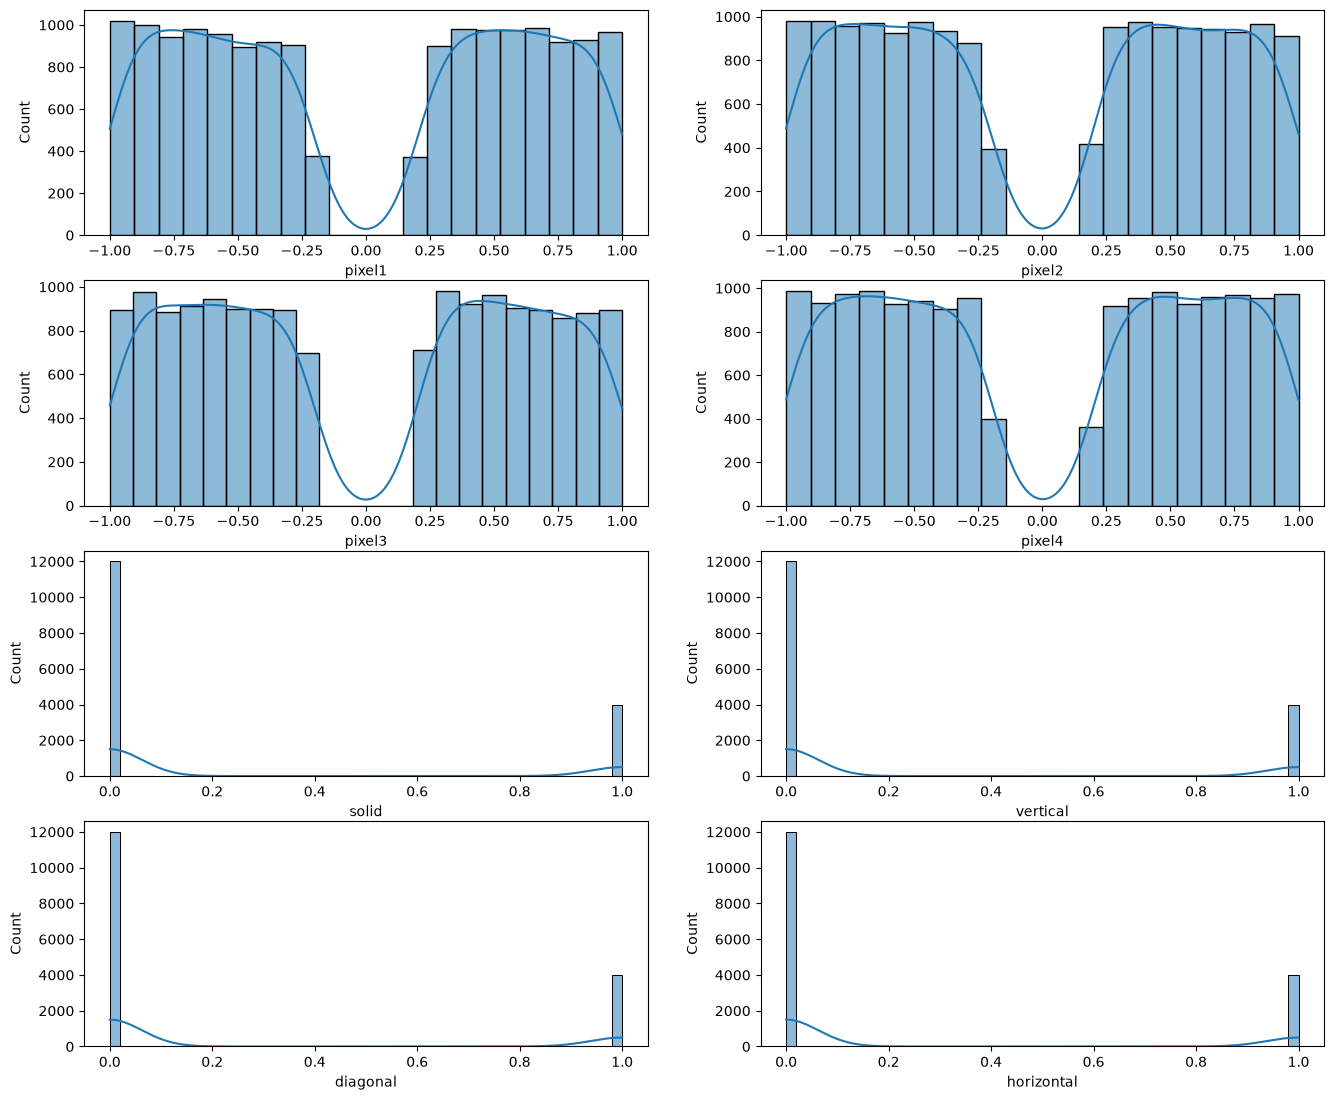

In [5]:
pos = 1
fig = plt.figure(figsize=(16,24))
for i in data.columns:
    ax = fig.add_subplot(7,2, pos)
    pos = pos + 1
    sns.histplot(data[i], ax=ax, kde=True)

# Splitting the data into input and output (X, y)

In [6]:
X = data.iloc[:, 0:4]
y = data.iloc[:, 4:8]

# Splitting the data into training, test, and validation sets

In [7]:
from sklearn.model_selection import train_test_split
train_ratio = 0.75
validation_ratio = 0.15
test_ratio = 0.10

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_ratio)

X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=test_ratio/(test_ratio + validation_ratio)) 

print (X_train.shape)
print (X_val.shape)
print (X_test.shape)

(12000, 4)
(2400, 4)
(1600, 4)


# Neural network
- Structure
  - Input layer
  - Hidden layer - 4 neurons, tanh activation function
  - Hidden layer - 4 neurons, tanh activation function
  - Hidden layer - 8 neurons, relu activation function
  - Output layer - linear activation function
- compile (optimizer="adam", loss="mse")
- summary 
- training the network

In [8]:
model = Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(4, activation = 'tanh'))
model.add(Dense(4, activation = 'tanh'))
model.add(Dense(8, activation = 'relu'))
model.add(Dense(4, activation = 'linear'))

In [9]:
model.compile(optimizer="adam", loss="mse")

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116 (464.00 B)

 Trainable params: 116 (464.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
from keras_visualizer import visualizer 
visualizer(model, file_format='png', view=True)

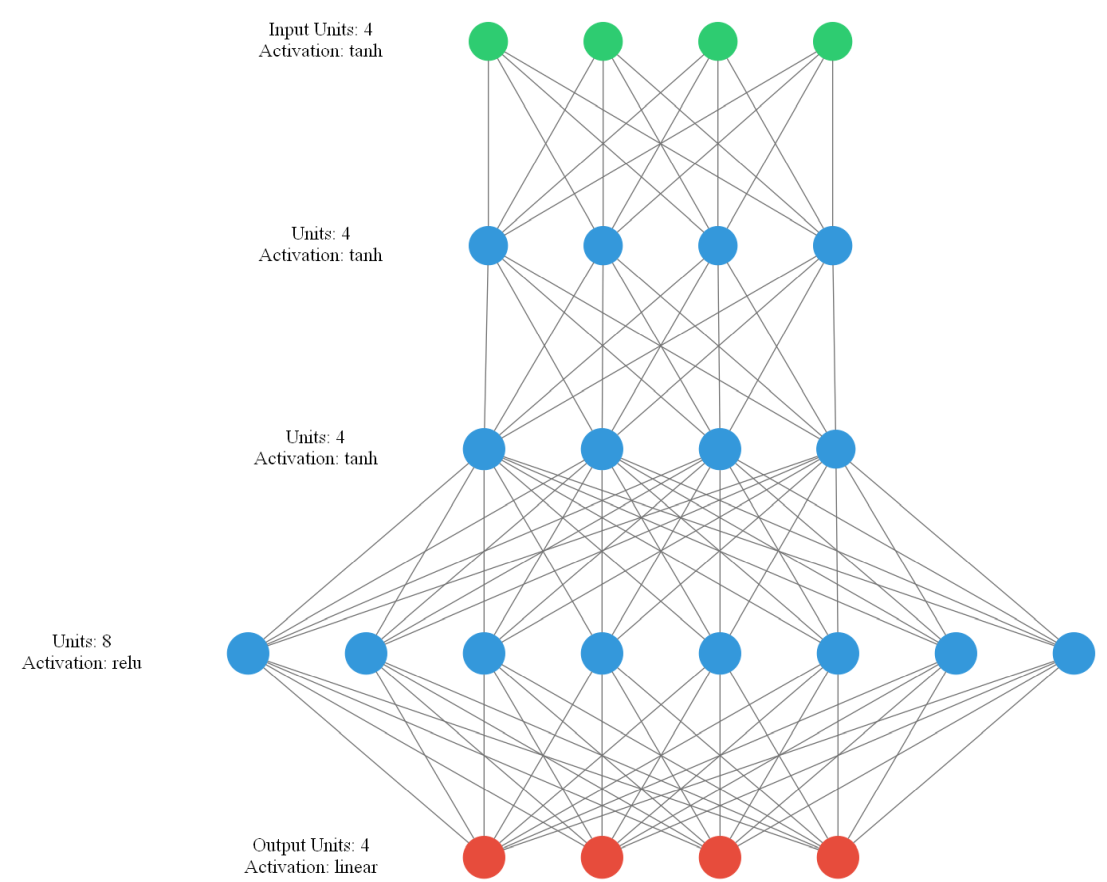

In [12]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=30)
history=model.fit(X_train, y_train, epochs = 1000, batch_size=1000, validation_data=(X_val, y_val), callbacks=[early_stop])

Epoch 1/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.2681 - val_loss: 0.2533
Epoch 2/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2408 - val_loss: 0.2300
Epoch 3/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2213 - val_loss: 0.2139
Epoch 4/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2077 - val_loss: 0.2024
Epoch 5/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1975 - val_loss: 0.1934
Epoch 6/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1892 - val_loss: 0.1858
Epoch 7/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1822 - val_loss: 0.1792
Epoch 8/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1760 - val_loss: 0.1734
Epoch 9/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1705 - val_loss: 0.1681
Epoch 10/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1654 - val_loss: 0.1633
Epoch 11/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1607 - val_loss: 0.1587
Epoch 12/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6

# Learning history
Displaying the learning history curve

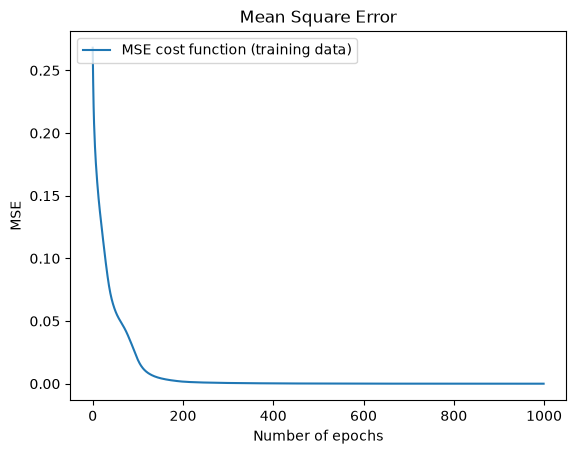

In [13]:
plt.plot(history.history['loss'], label='MSE cost function (training data)')
plt.title('Mean Square Error')
plt.ylabel('MSE')
plt.xlabel('Number of epochs')
plt.legend(loc="upper left")
plt.show()

# Calculating the model's R2 accuracy

In [14]:
y_pred = model.predict(X_test)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [15]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print('R2 score: {}'.format(r2))

R2 score: 0.9999773502349854


# Verification on your own data
The answer should be vertical, e.g. [0, 1, 0, 0]. Note that the 0s will most likely show up as very small numbers written in scientific notation.

In [16]:
data = np.array([0, 1, 0, 1])
data = data.reshape(1, -1)

In [17]:
y_pred = model.predict(data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


In [18]:
y_pred

array([[ 0.21995577,  0.7662752 ,  0.05915564, -0.02954892]],
      dtype=float32)